In [4]:
# =========================================
# 🏠 HOUSE PRICE PREDICTION PROJECT
# =========================================
# Objective:
# Predict house prices using machine learning

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
np.random.seed(42)

n = 300

data = pd.DataFrame({
    "area": np.random.randint(500, 4000, n),
    "bedrooms": np.random.randint(1, 5, n),
    "bathrooms": np.random.randint(1, 4, n),
    "age": np.random.randint(0, 30, n),
    "parking": np.random.randint(0, 2, n),
    "floors": np.random.randint(1, 3, n),
    "location_score": np.random.randint(1, 10, n)
})

data["price"] = (
    data["area"] * 3000 +
    data["bedrooms"] * 50000 +
    data["bathrooms"] * 30000 +
    data["floors"] * 40000 +
    data["location_score"] * 60000 -
    data["age"] * 10000 +
    data["parking"] * 40000 +
    np.random.randint(-50000, 50000, n)
)

data.head()

,area,bedrooms,bathrooms,age,parking,floors,location_score,price
0,3674,4,3,8,0,1,1,11308589
1,1360,1,3,2,1,2,1,4360015
2,1794,1,1,0,0,2,9,6061009
3,1630,4,2,20,0,1,8,5503309
4,1595,4,1,15,1,2,9,5537046


In [7]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area            300 non-null    int64
 1   bedrooms        300 non-null    int64
 2   bathrooms       300 non-null    int64
 3   age             300 non-null    int64
 4   parking         300 non-null    int64
 5   floors          300 non-null    int64
 6   location_score  300 non-null    int64
 7   price           300 non-null    int64
dtypes: int64(8)
memory usage: 18.9 KB


,area,bedrooms,bathrooms,age,parking,floors,location_score,price
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,2341.816667,2.556667,1.883333,14.646667,0.473333,1.490000,4.996667,7.441296e+06
std,995.267929,1.156683,0.827853,8.803037,0.500123,0.500735,2.683404,2.985655e+06
min,501.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.559961e+06
25%,1535.500000,2.000000,1.000000,6.750000,0.000000,1.000000,3.000000,4.974933e+06
50%,2281.000000,3.000000,2.000000,15.000000,0.000000,1.000000,5.000000,7.333187e+06
75%,3231.750000,4.000000,3.000000,22.000000,1.000000,2.000000,7.250000,1.012338e+07
max,3999.000000,4.000000,3.000000,29.000000,1.000000,2.000000,9.000000,1.274988e+07


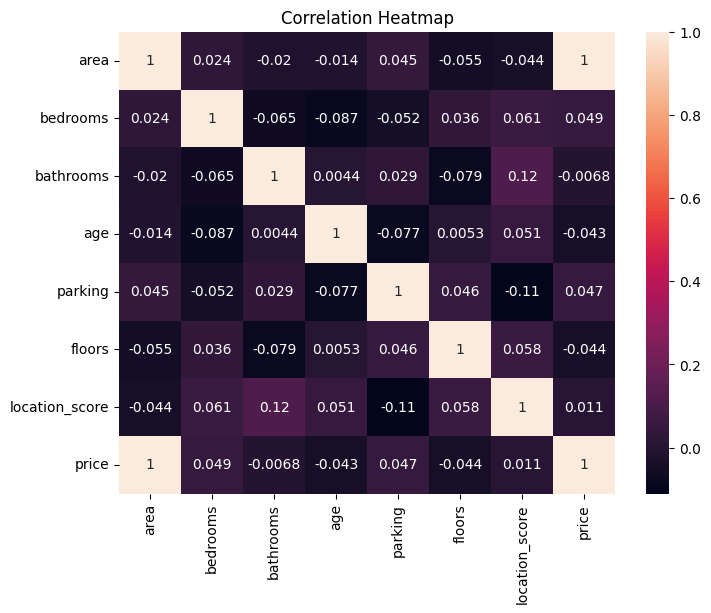

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

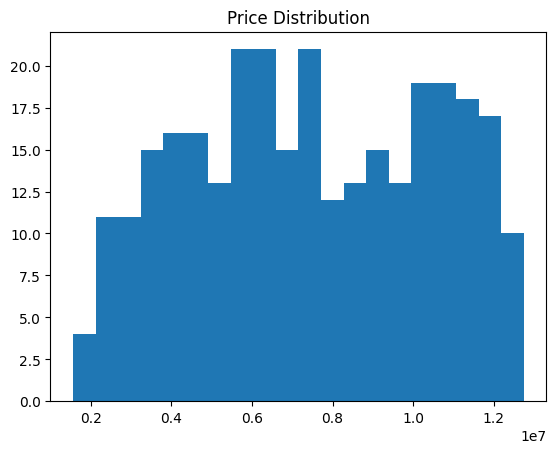

In [9]:
plt.hist(data["price"], bins=20)
plt.title("Price Distribution")
plt.show()

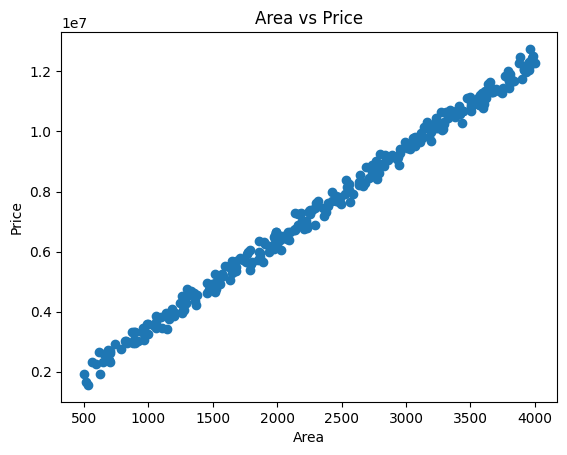

In [10]:
plt.scatter(data["area"], data["price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = data.drop("price", axis=1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Linear Regression:
MAE: 24868.301296190908
RMSE: 29521.67285261968
R2: 0.9998779613438016

Random Forest:
MAE: 123279.53616666664
RMSE: 162279.2064671474
R2: 0.9963124217810808


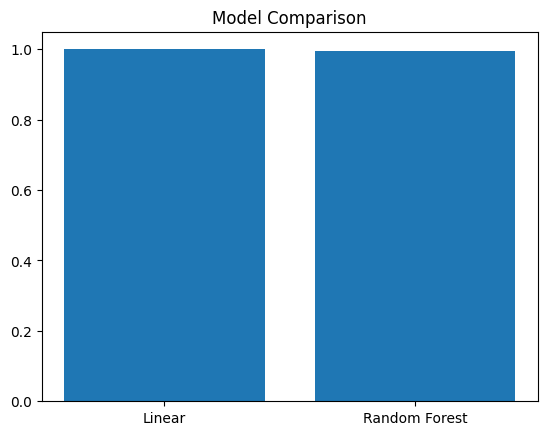

In [15]:
models = ["Linear", "Random Forest"]
scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.show()

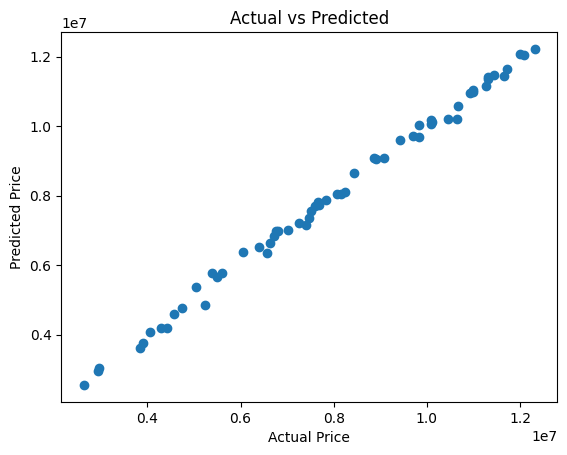

In [16]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

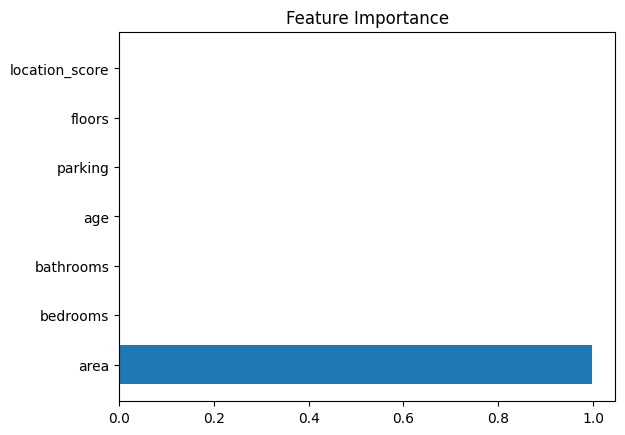

In [17]:
importance = rf.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [18]:
sample = [[2000, 3, 2, 5, 1, 2, 8]]

price = rf.predict(sample)

print("Predicted House Price:", price[0])

Predicted House Price: 6468674.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
